# 01 — Spam (mensagens SMS) — versão explicada

Este caderno ensina o computador a ler **mensagens de SMS** e dizer se cada uma é **spam (1)** ou uma mensagem **legítima (0)**. A única coisa que o modelo recebe é o texto.

Depois de treinar e comparar os modelos, transformamos a resposta do melhor deles num **"semáforo" de três faixas**: decidir sozinho que não, mandar para uma pessoa analisar, ou decidir sozinho que sim.

**Como usar:** rode as células de cima para baixo (menu *Ambiente de execução → Executar tudo*). Cada etapa tem um texto explicando o que vai acontecer, e o código tem um comentário (linhas começando com `#`) dizendo o que cada linha faz.

In [1]:
# Esta célula prepara o ambiente. Sempre rode ela primeiro.
try:
    # Esta linha só funciona dentro do Google Colab
    from google.colab import drive
    # Pede permissão e conecta o seu Google Drive ao Colab
    drive.mount('/content/drive')
    # Endereço da pasta do projeto dentro do Drive (troque se colocou em outro lugar)
    PROJECT_DIR = '/content/drive/MyDrive/a2'
    IN_COLAB = True
except ImportError:
    # Se deu erro acima, não estamos no Colab: usamos a pasta do projeto no computador
    import os
    PROJECT_DIR = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
    IN_COLAB = False
# Entra na pasta do projeto (como dar dois cliques nela)
%cd {PROJECT_DIR}
if IN_COLAB:
    # Instala as bibliotecas listadas no requirements.txt
    !pip install -q -r requirements.txt
# Avisa o Python para procurar o nosso código dentro da pasta do projeto (pasta src/)
import sys; sys.path.insert(0, PROJECT_DIR)

C:\Users\otavi\OneDrive\Desktop\data science\a2


In [2]:
# Qual domínio este caderno vai rodar
DOMAIN = "spam"
# False = usa os modelos já treinados e salvos (rápido). True = treina tudo de novo (demora)
FORCE_RETRAIN = False

# Bibliotecas: gráficos, contas com números e tabelas
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
# Ferramenta para mostrar imagens e tabelas dentro do caderno
from IPython.display import Image, display

# Nosso próprio código, que fica na pasta src/
from src import config, cutoff_hist, evaluate, explain, pipeline
# timed mede quanto tempo cada etapa demora
from src.pipeline import timed

# Configurações deste domínio (classe positiva, métrica, limites de erro...)
cfg = config.DOMAINS[DOMAIN]
# Pasta onde os resultados vão ser salvos: outputs/<domínio>/
OUT = config.output_dir(DOMAIN)
# Subpasta dos resultados da Parte 1 (faixas de decisão)
FX = OUT / "faixas"
# Limiar de decisão: probabilidade >= 0,5 vira "positivo"
T = config.THRESHOLD
# Lista para anotar todas as figuras geradas
FIGS = []

def show(path):
    # Anota a figura na lista e mostra ela na tela
    FIGS.append(path.relative_to(OUT).as_posix())
    display(Image(filename=str(path)))

def table(df, stem):
    # Salva a tabela em CSV e em Markdown dentro de outputs/ e mostra na tela
    evaluate.save_table(df, OUT / stem)
    display(evaluate.round_table(df))

print(f"Domínio: {DOMAIN} | classe positiva: {cfg['positive_question']} | "
      f"métrica-alvo: {cfg['target_metric']} | limiar das métricas: {T}")

Domínio: spam | classe positiva: é spam? | métrica-alvo: average_precision | limiar das métricas: 0.5


## 1. Carregar os dados

Lemos o arquivo CSV da base e separamos em duas partes:
- **X** = as características, ou seja, o que o modelo pode olhar;
- **y** = a resposta certa de cada linha: **1** = spam ("é spam?") e **0** = legítima.

In [3]:
# Liga o cronômetro desta etapa
with timed("carregar dados"):
    # Lê data/<domínio>.csv e separa em X (características) e y (resposta certa, 0 ou 1)
    X, y = pipeline.load_domain_data(DOMAIN)
# Mostra o tamanho da base e quantos positivos existem
print(f"X: {X.shape} | positivos (target = 1): {y.sum()} ({100 * y.mean():.2f}%)")

[tempo] carregar dados: 0.0 s
X: (5171,) | positivos (target = 1): 653 (12.63%)


### Conferência
No spam, o `X` tem que ser o **texto puro** das mensagens. O computador só vai transformar o texto em números **dentro** do pipeline, na etapa 4.

In [4]:
# Mostra as 5 primeiras mensagens, para ver que é texto mesmo
print(X.head())
# Garante que X é texto (object) e não números
assert X.dtype == object, "no spam, X deve ser o texto bruto"

0    Go until jurong point, crazy.. Available only ...
1                        Ok lar... Joking wif u oni...
2    Free entry in 2 a wkly comp to win FA Cup fina...
3    U dun say so early hor... U c already then say...
4    Nah I don't think he goes to usf, he lives aro...
Name: text, dtype: object


## 2. Balanceamento das classes

Contamos quantas linhas são **spam** e quantas são **legítima**. Isso importa porque, quando uma classe é muito rara, um modelo "preguiçoso" que sempre chuta a classe comum parece ótimo na acurácia, mas não serve para nada.

,classe,n,pct_do_total
0,1 = spam (é spam?),653,12.63
1,0 = ham (legítima),4518,87.37
2,Total,5171,100.00


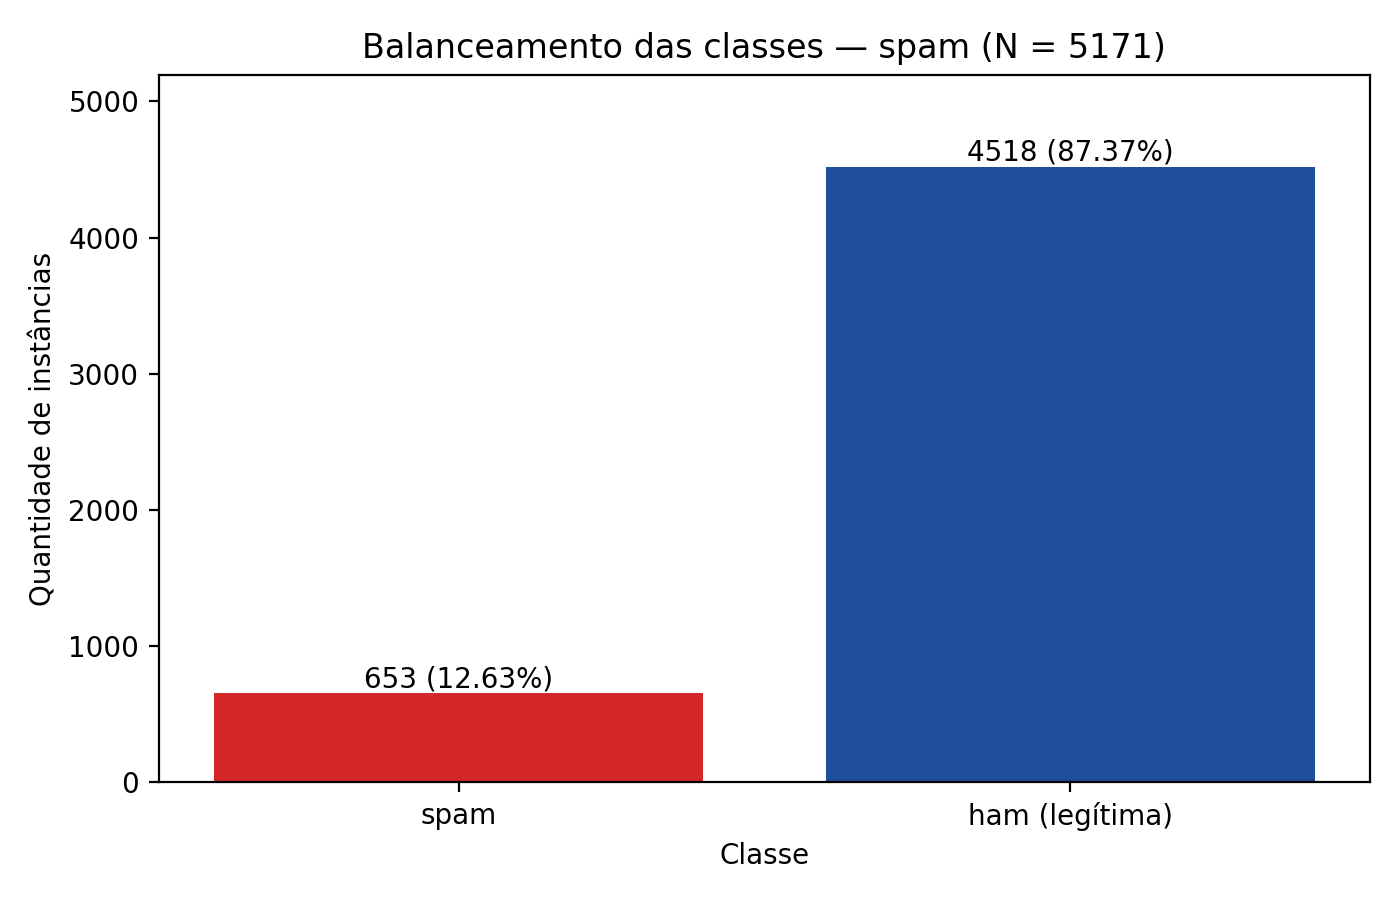

In [5]:
# Monta a tabela com a quantidade e o % de cada classe
balanceamento = evaluate.class_balance_table(y, cfg)
# Salva a tabela em outputs/ e mostra na tela
table(balanceamento, "balanceamento")
# Desenha o gráfico de barras das classes, salva e mostra
show(evaluate.plot_class_balance(y, cfg, OUT / "01_balanceamento_classes.png",
                                 f"Balanceamento das classes — {DOMAIN} (N = {len(y)})"))

## 3. Separar em treino, validação e teste (60% / 20% / 20%)

Pense numa escola:
- **Treino (60%)** = o material de estudo. O modelo aprende aqui.
- **Validação (20%)** = o simulado. Serve para comparar os modelos e escolher o melhor, e para escolher os cortes t1 e t2.
- **Teste (20%)** = a prova final. Só usamos **uma vez**, no fim, para ver a nota verdadeira.

A separação é **estratificada**: cada parte fica com a mesma proporção de spam da base inteira.

In [6]:
# Liga o cronômetro desta etapa
with timed("split"):
    # Divide em 60% treino, 20% validação e 20% teste, mantendo a proporção de positivos
    splits = pipeline.split_data(X, y)
# Pega as características e as respostas de cada parte
X_tr, y_tr = splits["treino"]
X_val, y_val = splits["validacao"]
X_te, y_te = splits["teste"]
# Mostra o tamanho de cada parte e o % de positivos em cada uma
table(pipeline.split_table(splits), "split")

[tempo] split: 0.0 s


,conjunto,n,pct_do_total,n_positivos,pct_positivos,n_negativos
0,treino,3102,59.99,392,12.64,2710
1,validacao,1034,20.00,130,12.57,904
2,teste,1035,20.02,131,12.66,904


## 4. Treinar 3 algoritmos e escolher os melhores "botões" de cada um

Cada algoritmo tem **hiperparâmetros**, que são como botões de regulagem. Para achar a melhor regulagem, usamos **validação cruzada com 5 partes**: o treino é dividido em 5 pedaços; o modelo treina em 4 e é testado no 5º, e isso se repete 5 vezes trocando o pedaço. A nota de cada regulagem é a média das 5 vezes.

Tudo roda dentro de um **Pipeline**: a preparação dos dados (transformar texto em números, padronizar escalas) é aprendida só com o pedaço de treino de cada rodada. Isso evita "cola": o modelo nunca espia os dados em que vai ser avaliado.

Depois de treinado, cada modelo é salvo em `outputs/spam/models/`. Na próxima vez, ele é só carregado, sem precisar treinar de novo.

In [7]:
# Treina (ou carrega, se já estiver salvo) os 3 algoritmos, testando as regulagens por validação cruzada
tuned = pipeline.tune_all(DOMAIN, X_tr, y_tr, force_retrain=FORCE_RETRAIN)
# Monta a tabela com a melhor regulagem de cada algoritmo e a nota média na validação cruzada
hiperparametros = pipeline.hyperparams_table(tuned, cfg["target_metric"])
# Salva e mostra a tabela
table(hiperparametros, "hiperparametros")

[checkpoint] Regressão Logística: carregado de regressao_logistica.joblib
[tempo] tuning Regressão Logística: 0.1 s
[checkpoint] Naive Bayes Multinomial: carregado de naive_bayes_multinomial.joblib
[tempo] tuning Naive Bayes Multinomial: 0.0 s
[checkpoint] LinearSVC calibrado: carregado de linearsvc_calibrado.joblib
[tempo] tuning LinearSVC calibrado: 0.1 s


,modelo,metrica_cv,cv_average_precision_media,cv_average_precision_desvio,cv_folds,candidatos_testados,tempo_tuning_s,melhores_hiperparametros
0,Regressão Logística,average_precision,0.9736,0.0119,5,48,33.6023,"C=10; tfidf__min_df=1; tfidf__ngram_range=(1, ..."
1,Naive Bayes Multinomial,average_precision,0.9715,0.0130,5,60,6.9058,alpha=0.1; tfidf__min_df=2; tfidf__ngram_range...
2,LinearSVC calibrado,average_precision,0.9744,0.0119,5,48,5.0927,estimator__C=1; tfidf__min_df=1; tfidf__ngram_...


## 5. Comparar os 3 modelos no "simulado" (validação)

Cada modelo dá, para cada linha, uma **probabilidade de ser spam**, de 0 a 1. Para decidir "sim" ou "não", usamos o **limiar 0,5**: probabilidade ≥ 0,5 vira spam.

- **Acurácia**: % de acertos no geral.
- **Precisão**: quando o modelo diz "spam", quantas vezes ele acerta?
- **Recall**: de todos os spam que existem, quantos o modelo encontrou?
- **F1**: junta precisão e recall numa nota só.
- **ROC-AUC**, **PR-AUC** e **AP**: notas que não dependem do limiar (explicadas na etapa 7).
- **Matriz de confusão**: tabela com os 4 tipos de resultado (acertos e erros de cada lado).

[tempo] avaliação na validação: 0.1 s


,modelo,limiar,acuracia,precisao,recall,f1,roc_auc,pr_auc_trapezoidal,average_precision_AP,TN,FP,FN,TP
0,Regressão Logística,0.5,0.9816,0.9664,0.8846,0.9237,0.9956,0.9789,0.9790,900,4,15,115
1,Naive Bayes Multinomial,0.5,0.9845,1.0000,0.8769,0.9344,0.9887,0.9678,0.9678,904,0,16,114
2,LinearSVC calibrado,0.5,0.9826,0.9118,0.9538,0.9323,0.9956,0.9769,0.9770,892,12,6,124


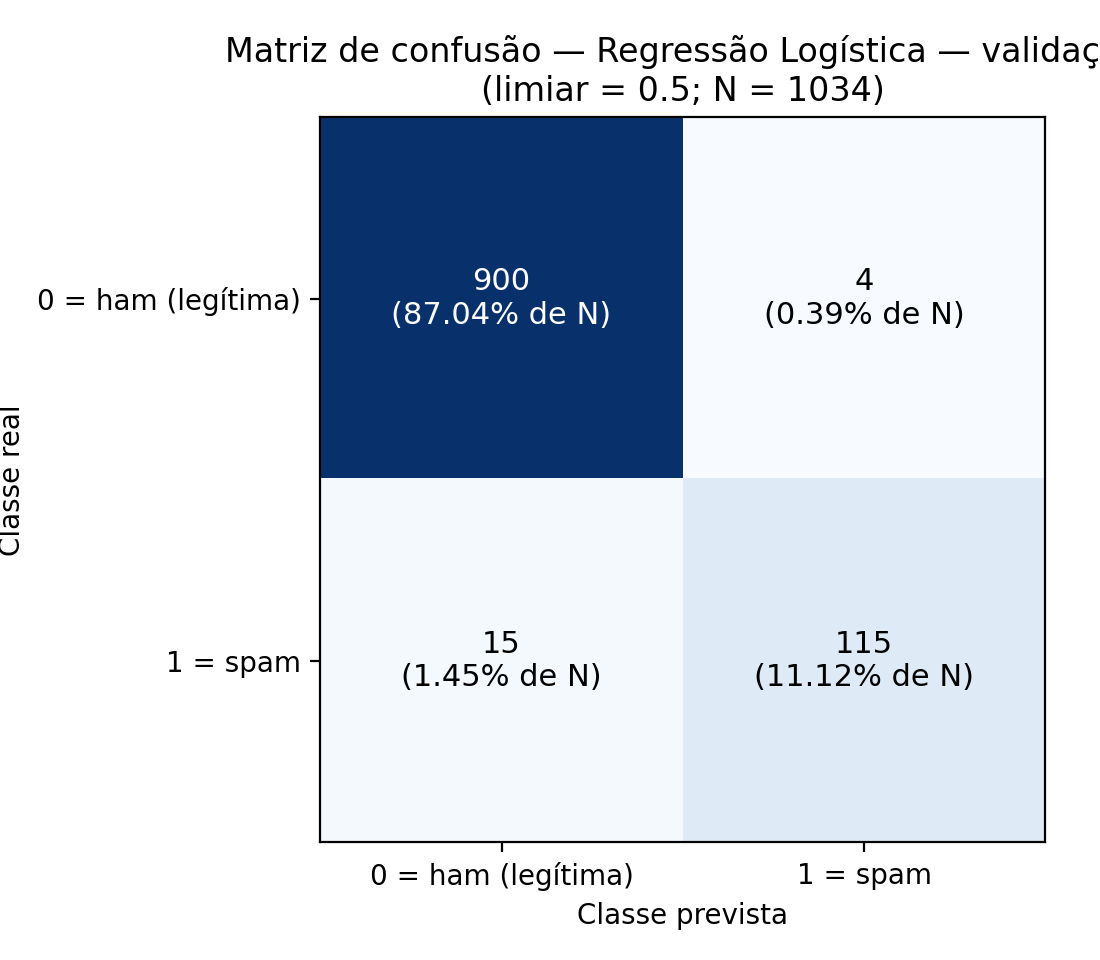

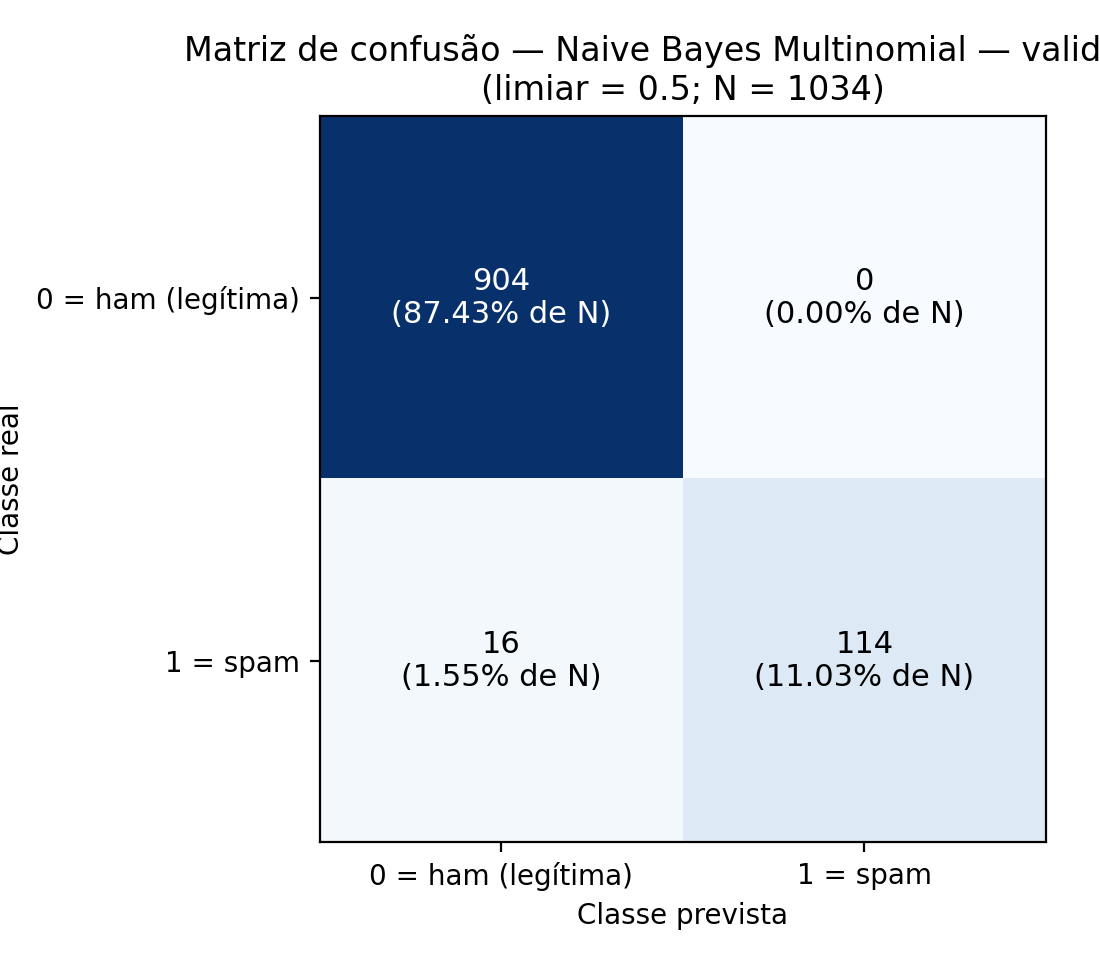

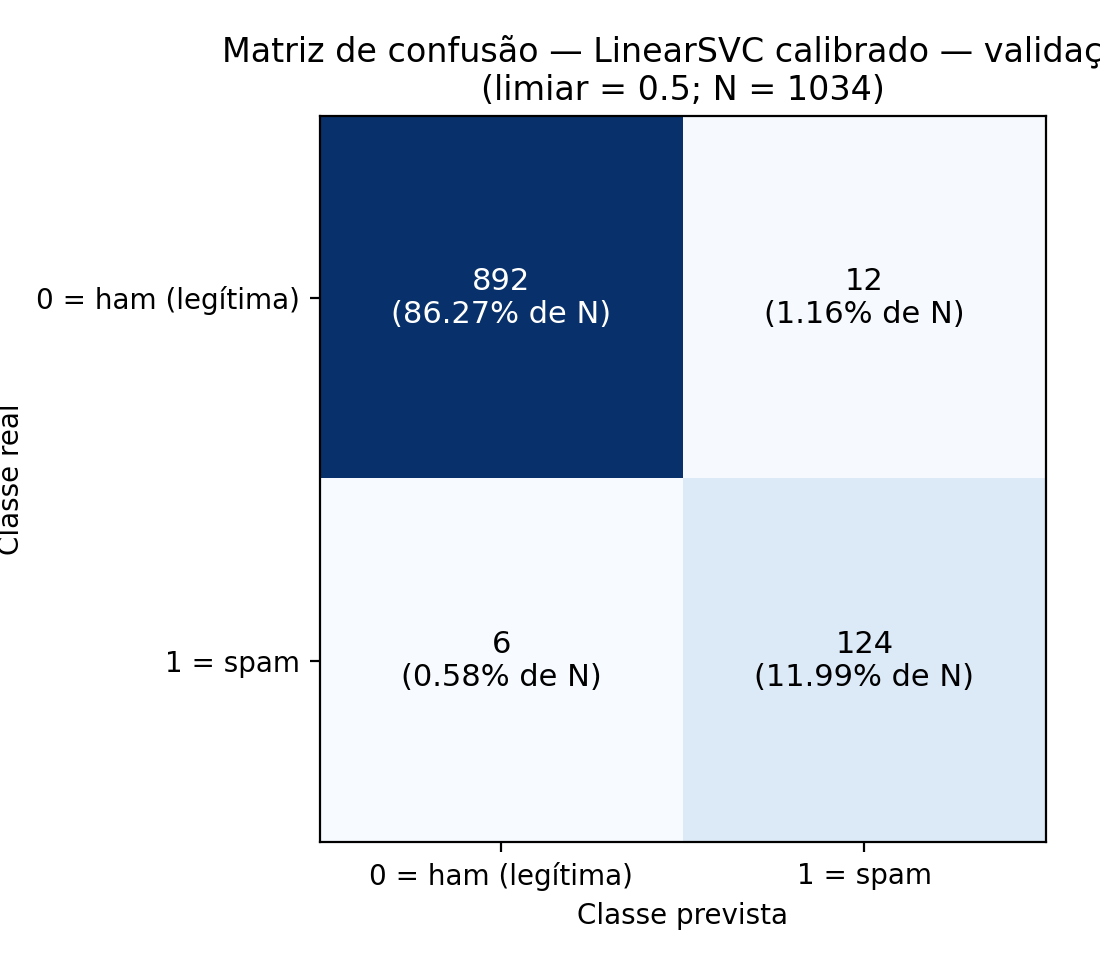

In [8]:
# Liga o cronômetro desta etapa
with timed("avaliação na validação"):
    # Para cada modelo, calcula a probabilidade de ser positivo de TODAS as linhas da validação
    val_probas = {name: pipeline.predict_positive(ck["estimator"], X_val)
                  for name, ck in tuned.items()}
    # Calcula todas as métricas de cada modelo (limiar 0,5 nas que precisam de decisão)
    comparacao = evaluate.comparison_table(y_val, val_probas)
# Salva e mostra a tabela comparando os 3 modelos
table(comparacao, "comparacao_validacao")
# Para cada modelo, desenha a matriz de confusão
for name, p in val_probas.items():
    show(evaluate.plot_confusion(
        y_val, p, cfg, OUT / f"02_matriz_confusao_validacao_{pipeline.slug(name)}.png",
        f"Matriz de confusão — {name} — validação"))

## 6. Escolher o melhor modelo

O vencedor é o de maior nota na métrica escolhida para este domínio: **Average Precision (AP)**. Só 13% das mensagens são spam, então a acurácia engana. A AP mede se, quando o modelo aponta "spam", ele costuma acertar, em todos os níveis de exigência.

In [9]:
# Escolhe o modelo com a maior métrica-alvo na validação
best_name, best_col, best_value = evaluate.select_best(comparacao, cfg["target_metric"])
# Guarda o modelo vencedor para usar nas próximas etapas
best = tuned[best_name]["estimator"]
# Frase que resume a escolha
selecao = f"{best_name} — maior {best_col} na validação = {best_value:.4f}"
print("Melhor modelo:", selecao)

Melhor modelo: Regressão Logística — maior average_precision_AP na validação = 0.9790


## 7. Curvas ROC e Precisão-Revocação (PR)

Em vez de usar só o limiar 0,5, as curvas testam **todos os limiares** de 0 a 1:
- **Curva ROC**: para cada limiar, marca um ponto com a taxa de alarmes falsos (eixo X) e a taxa de spam encontrados (eixo Y). A **área embaixo da curva (ROC-AUC)** vai de 0,5 (chute) a 1 (perfeito).
- **Curva PR**: para cada limiar, marca um ponto com o recall (eixo X) e a precisão (eixo Y). A linha tracejada é o chute (a proporção de spam). A área pode ser calculada de dois jeitos: **PR-AUC trapezoidal** (liga os pontos com retas) e **Average Precision** (soma em degraus).

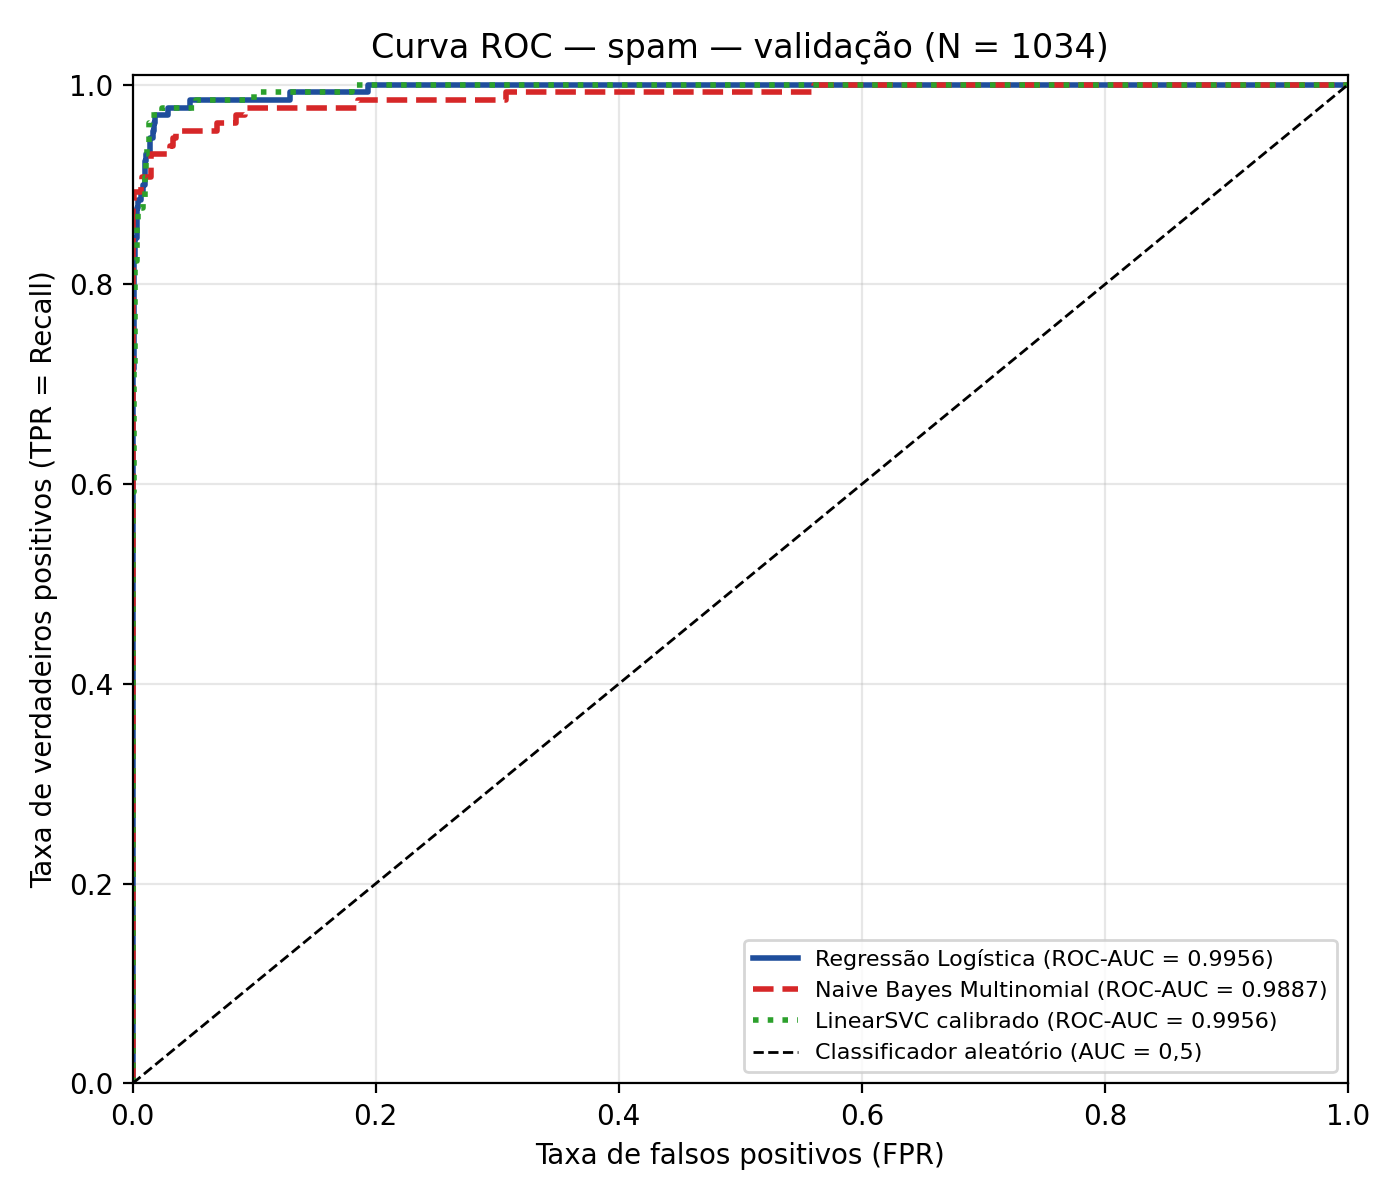

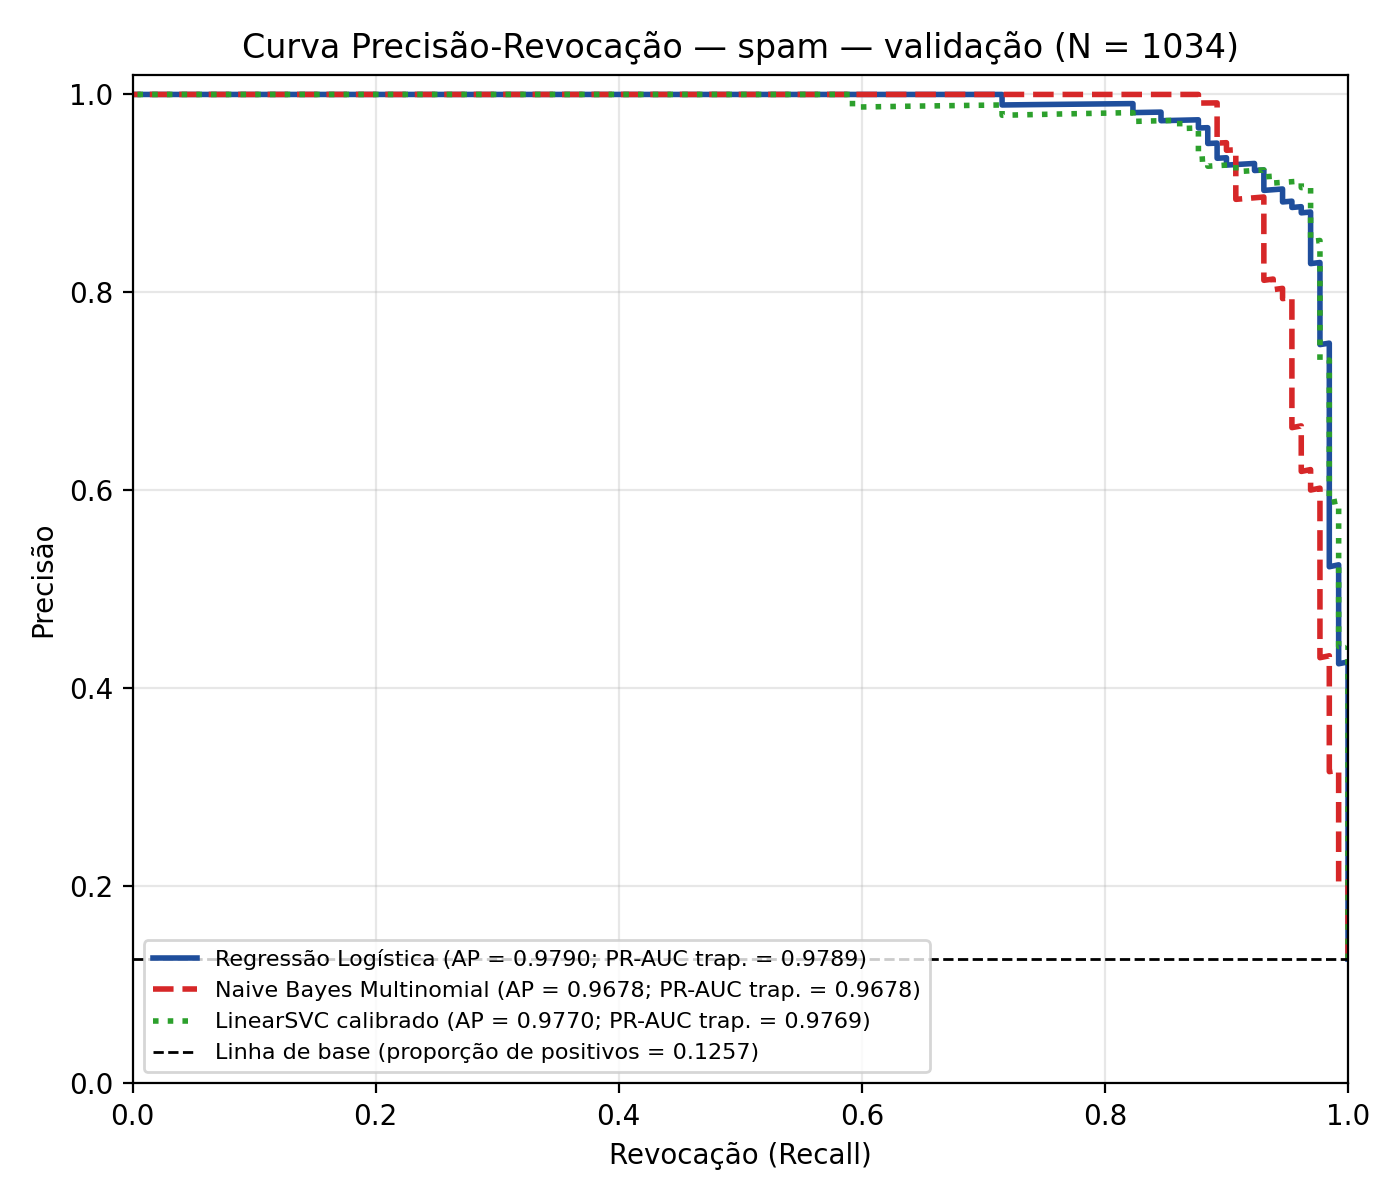

In [10]:
# Quantidade de linhas da validação (vai no título dos gráficos)
n_val = len(y_val)
# Desenha as curvas ROC dos 3 modelos juntas
show(evaluate.plot_roc(y_val, val_probas, OUT / "03_curva_roc_validacao.png",
                       f"Curva ROC — {DOMAIN} — validação (N = {n_val})"))
# Desenha as curvas Precisão-Revocação dos 3 modelos juntas
show(evaluate.plot_pr(y_val, val_probas, OUT / "04_curva_pr_validacao.png",
                      f"Curva Precisão-Revocação — {DOMAIN} — validação (N = {n_val})"))

## 8. O que acontece quando mudamos o limiar

Esta tabela mostra o melhor modelo com limiares de 0,1 a 0,9. Limiar **baixo** = o modelo diz "spam" com facilidade: encontra mais spam, mas dá mais alarmes falsos. Limiar **alto** = o contrário. Cada linha da tabela é um ponto das curvas da etapa 7.

In [11]:
# Calcula acertos e erros do melhor modelo para os limiares 0,1; 0,2; ...; 0,9
varredura = evaluate.threshold_sweep(y_val, val_probas[best_name])
# Salva e mostra a tabela
table(varredura, "varredura_limiar")

,limiar,TP,FP,TN,FN,TPR_recall,FPR,precisao
0,0.1,127,28,876,3,0.9769,0.0310,0.8194
1,0.2,123,13,891,7,0.9462,0.0144,0.9044
2,0.3,120,9,895,10,0.9231,0.0100,0.9302
3,0.4,116,7,897,14,0.8923,0.0077,0.9431
4,0.5,115,4,900,15,0.8846,0.0044,0.9664
5,0.6,109,2,902,21,0.8385,0.0022,0.9820
6,0.7,107,1,903,23,0.8231,0.0011,0.9907
7,0.8,97,1,903,33,0.7462,0.0011,0.9898
8,0.9,66,0,904,64,0.5077,0.0000,1.0000


## 9. A "prova final": avaliar o melhor modelo no teste

Agora, e só agora, usamos o teste. O modelo **não é retreinado e nada é ajustado**: é a nota verdadeira, em dados que o modelo nunca viu e que não influenciaram nenhuma escolha.

[tempo] avaliação no teste: 0.0 s


,modelo,conjunto,limiar,acuracia,precisao,recall,f1,roc_auc,pr_auc_trapezoidal,average_precision_AP,TN,FP,FN,TP
0,Regressão Logística,teste,0.5,0.9807,0.9912,0.855,0.918,0.9903,0.9664,0.9665,903,1,19,112


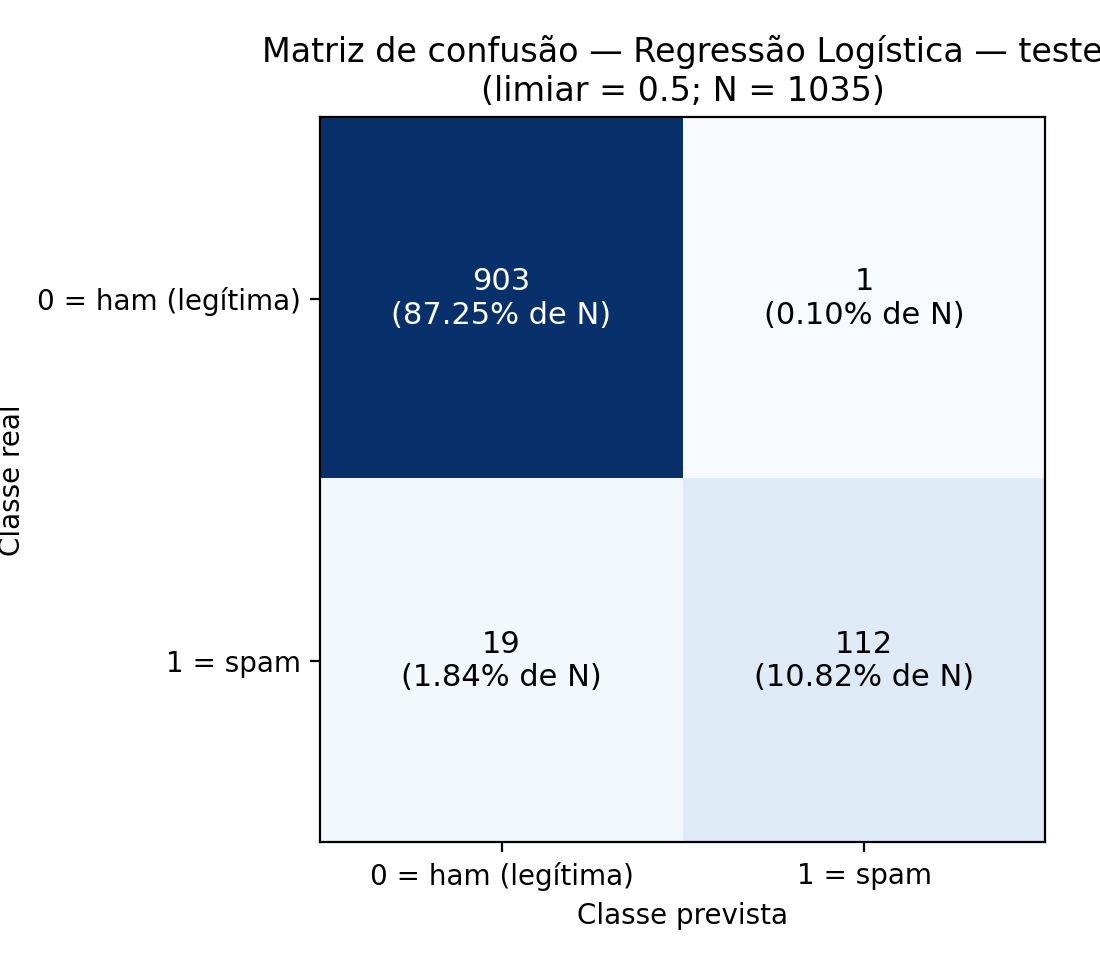

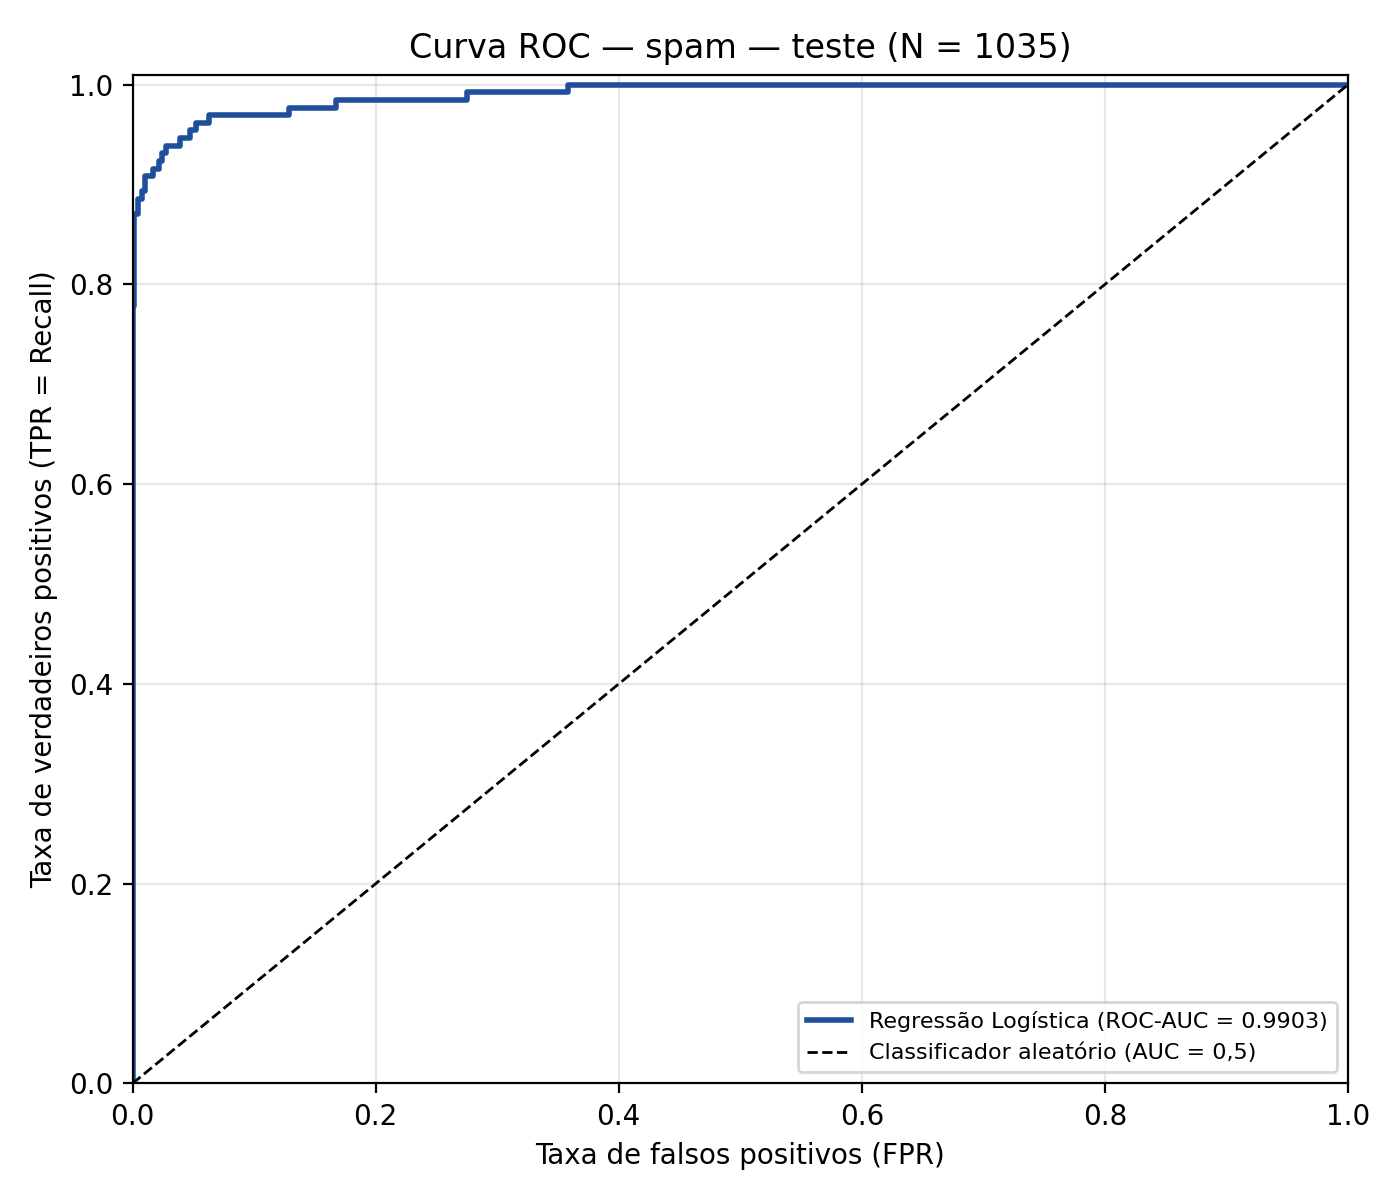

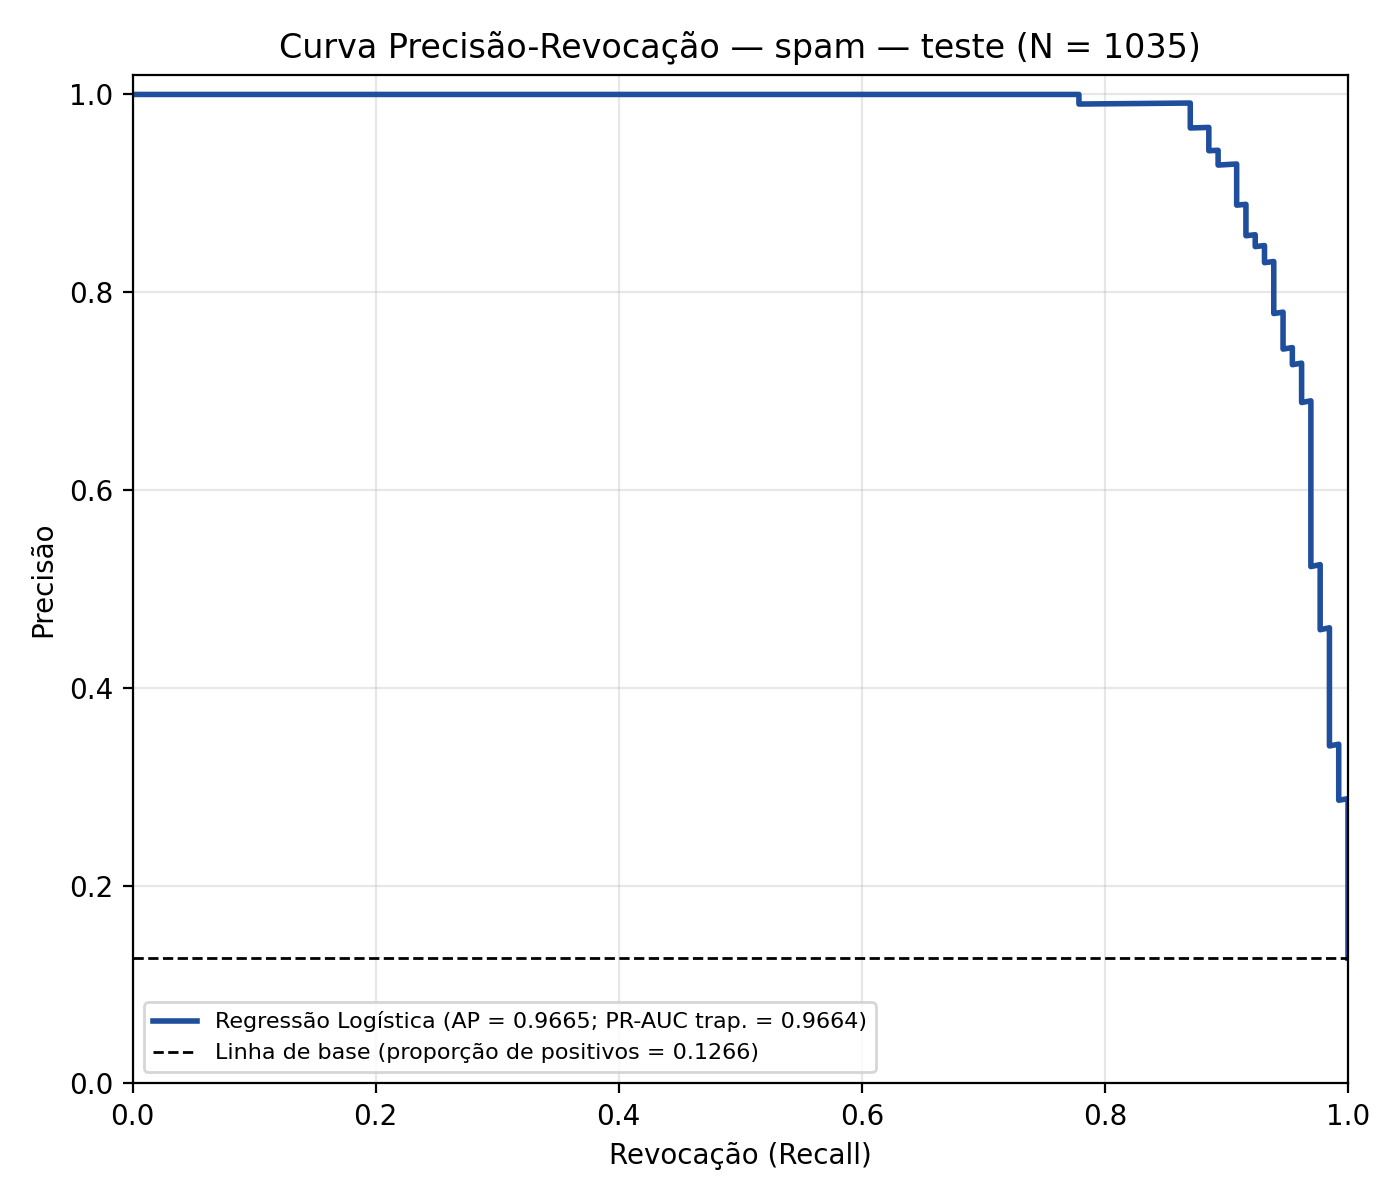

In [12]:
# Liga o cronômetro desta etapa
with timed("avaliação no teste"):
    # Probabilidade de ser positivo para TODAS as linhas do teste
    p_test = pipeline.predict_positive(best, X_te)
    # Calcula as mesmas métricas da etapa 5, agora no teste
    resultado_teste = evaluate.comparison_table(y_te, {best_name: p_test})
# Acrescenta uma coluna dizendo que estes números são do teste
resultado_teste.insert(1, "conjunto", "teste")
# Salva e mostra a tabela
table(resultado_teste, "resultado_teste")
# Quantidade de linhas do teste (vai no título dos gráficos)
n_te = len(y_te)
# Matriz de confusão, curva ROC e curva PR do melhor modelo no teste
show(evaluate.plot_confusion(y_te, p_test, cfg, OUT / "05_matriz_confusao_teste.png",
                             f"Matriz de confusão — {best_name} — teste"))
show(evaluate.plot_roc(y_te, {best_name: p_test}, OUT / "06_curva_roc_teste.png",
                       f"Curva ROC — {DOMAIN} — teste (N = {n_te})"))
show(evaluate.plot_pr(y_te, {best_name: p_test}, OUT / "07_curva_pr_teste.png",
                      f"Curva Precisão-Revocação — {DOMAIN} — teste (N = {n_te})"))

## 10. SHAP: o que o modelo levou em conta?

O SHAP mostra **quanto cada característica empurrou a resposta do modelo para cima ou para baixo**. Como ler o gráfico:
- cada **linha** é uma característica, e a mais importante fica no topo;
- cada **ponto** é uma linha do teste;
- ponto à **direita** do zero = aquela característica aumentou a chance de spam; à **esquerda** = diminuiu;
- **cor**: vermelho = valor alto da característica; azul = valor baixo.

O texto impresso embaixo do gráfico diz qual saída do modelo foi explicada e quais dados foram usados.

[tempo] SHAP: 2.0 s


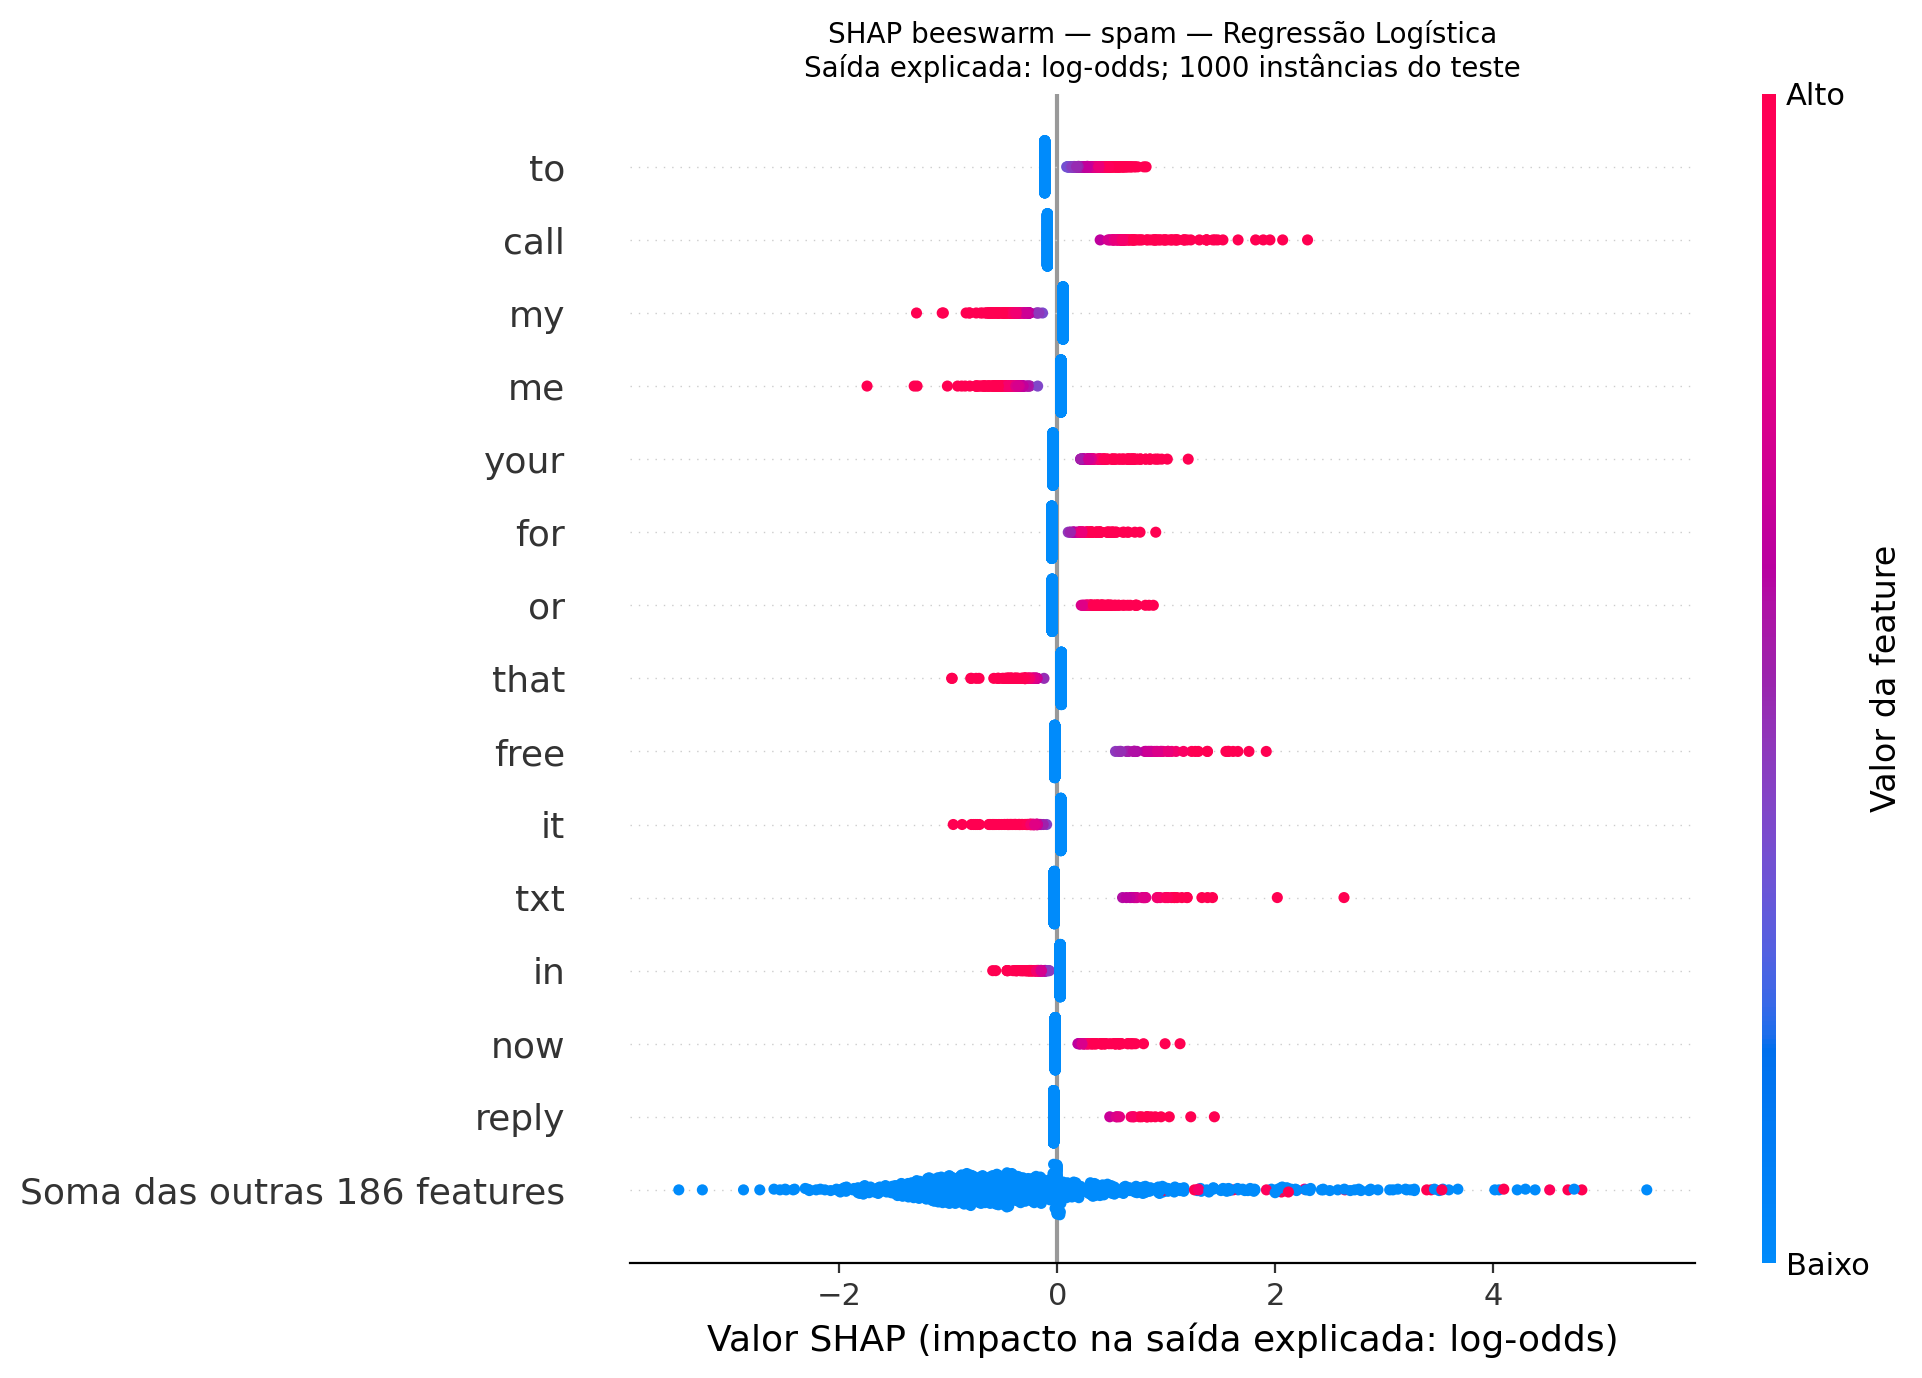

Domínio: spam
Modelo explicado: Regressão Logística (LogisticRegression)
Explainer: LinearExplainer (interventional)
Saída do modelo explicada: log-odds (escala linear) da classe positiva da Regressão Logística
Dados explicados: 1000 instâncias aleatórias do conjunto de TESTE (random_state=42), transformadas pelo pré-processamento do pipeline
Conjunto de fundo (background): 100 instâncias aleatórias do TREINO
Número de features após o pré-processamento: 34311
Beeswarm: max_display=15; cor = valor da feature (vermelho alto, azul baixo); eixo X = contribuição SHAP para a saída explicada
Somente as 200 features de maior média |SHAP| foram mantidas para o gráfico (vocabulário TF-IDF muito grande).


,posicao,feature,media_abs_shap,correlacao_valor_shap,leitura
0,1,to,0.1831,1.0,valores altos aumentam a saída
1,2,call,0.1637,1.0,valores altos aumentam a saída
2,3,my,0.0988,-1.0,valores altos diminuem a saída
3,4,me,0.0939,-1.0,valores altos diminuem a saída
4,5,your,0.0894,1.0,valores altos aumentam a saída
5,6,for,0.0763,1.0,valores altos aumentam a saída
6,7,or,0.0737,1.0,valores altos aumentam a saída
7,8,that,0.0688,-1.0,valores altos diminuem a saída
8,9,free,0.0657,1.0,valores altos aumentam a saída
9,10,it,0.0647,-1.0,valores altos diminuem a saída


In [13]:
# Liga o cronômetro desta etapa
with timed("SHAP"):
    # Calcula o SHAP numa amostra de até 1.000 linhas do teste, usando 100 linhas do treino como referência
    shap_res = explain.explain_model(DOMAIN, best_name, best, X_tr, X_te, OUT,
                                     OUT / "08_shap_beeswarm.png")
# Mostra o gráfico beeswarm
show(OUT / "08_shap_beeswarm.png")
# Mostra qual saída foi explicada e quais dados foram usados
print("\n".join(shap_res["info"]))
# Mostra as 10 características mais importantes
display(evaluate.round_table(shap_res["top10"]))

## 11. Parte 1: o "semáforo" de decisões

Com a probabilidade do melhor modelo, criamos três faixas usando dois cortes, **t1** e **t2**:
- 🟢 **p < t1** → o sistema decide **legítima** sozinho;
- 🟡 **t1 ≤ p < t2** → **uma pessoa analisa**;
- 🔴 **p ≥ t2** → o sistema decide **spam** sozinho.

**Como os cortes são escolhidos:** só na validação, testando todos os pares de 0,00 a 1,00. Um par só vale se respeitar os limites de erro deste domínio. Aqui, o erro mais grave é mandar uma mensagem legítima para o lixo (a pessoa pode perder algo importante), e o mais leve é deixar um spam chegar na caixa de entrada (é só um incômodo). Entre os pares que valem, fica o que manda **menos casos para a pessoa analisar**.

**No histograma:** o eixo X é a probabilidade de 0% a 100%. As barras **azuis** são todas as linhas e as **vermelhas** são só as que são spam de verdade. **As duas usam o mesmo total N** como base do %.

t1 = 0.11 | t2 = 0.70  (max_fn_rate = 0.03 sobre positivos, max_fp_rate = 0.002 sobre negativos)


,t1,t2,volume_manual,cobertura_automatica,fn_auto,fn_auto_sobre_positivos,fp_auto,fp_auto_sobre_negativos,violacao,viavel
0,0.11,0.70,0.0435,0.9565,3,0.0231,1,0.0011,0.0,True
1,0.11,0.71,0.0445,0.9555,3,0.0231,1,0.0011,0.0,True
2,0.10,0.70,0.0455,0.9545,3,0.0231,1,0.0011,0.0,True
3,0.11,0.72,0.0464,0.9536,3,0.0231,1,0.0011,0.0,True
4,0.10,0.71,0.0464,0.9536,3,0.0231,1,0.0011,0.0,True
5,0.11,0.73,0.0474,0.9526,3,0.0231,1,0.0011,0.0,True
6,0.11,0.74,0.0474,0.9526,3,0.0231,1,0.0011,0.0,True
7,0.11,0.75,0.0484,0.9516,3,0.0231,1,0.0011,0.0,True
8,0.10,0.72,0.0484,0.9516,3,0.0231,1,0.0011,0.0,True
9,0.10,0.73,0.0493,0.9507,3,0.0231,1,0.0011,0.0,True


,faixa,regra,n,pct_populacao_sobre_N,n_positivos,pct_positivos_sobre_n_faixa,n_negativos,pct_negativos_sobre_n_faixa
0,Negativa automática,p < t1,881,85.20,3,0.34,878,99.66
1,Análise manual,t1 ≤ p < t2,45,4.35,20,44.44,25,55.56
2,Positiva automática,p ≥ t2,108,10.44,107,99.07,1,0.93
3,Total,"t1 = 0.11, t2 = 0.7",1034,100.00,130,12.57,904,87.43


,metrica,valor,valor_pct,numerador,denominador,descricao_denominador,descricao
0,fn_auto,3.0000,NaN,3,<NA>,— (contagem),positivos classificados automaticamente como n...
1,fn_auto_sobre_positivos,0.0231,2.31,3,130,total de positivos,proporção dos positivos que caíram na faixa ne...
2,fn_auto_sobre_N,0.0029,0.29,3,1034,N (total de instâncias),proporção de N que é positivo e caiu na faixa ...
3,fp_auto,1.0000,NaN,1,<NA>,— (contagem),negativos classificados automaticamente como p...
4,fp_auto_sobre_negativos,0.0011,0.11,1,904,total de negativos,proporção dos negativos que caíram na faixa po...
5,fp_auto_sobre_N,0.0010,0.10,1,1034,N (total de instâncias),proporção de N que é negativo e caiu na faixa ...
6,cobertura_automatica,0.9565,95.65,989,1034,N (total de instâncias),proporção de N decidida automaticamente (fora ...
7,volume_manual,0.0435,4.35,45,1034,N (total de instâncias),proporção de N encaminhada à análise manual


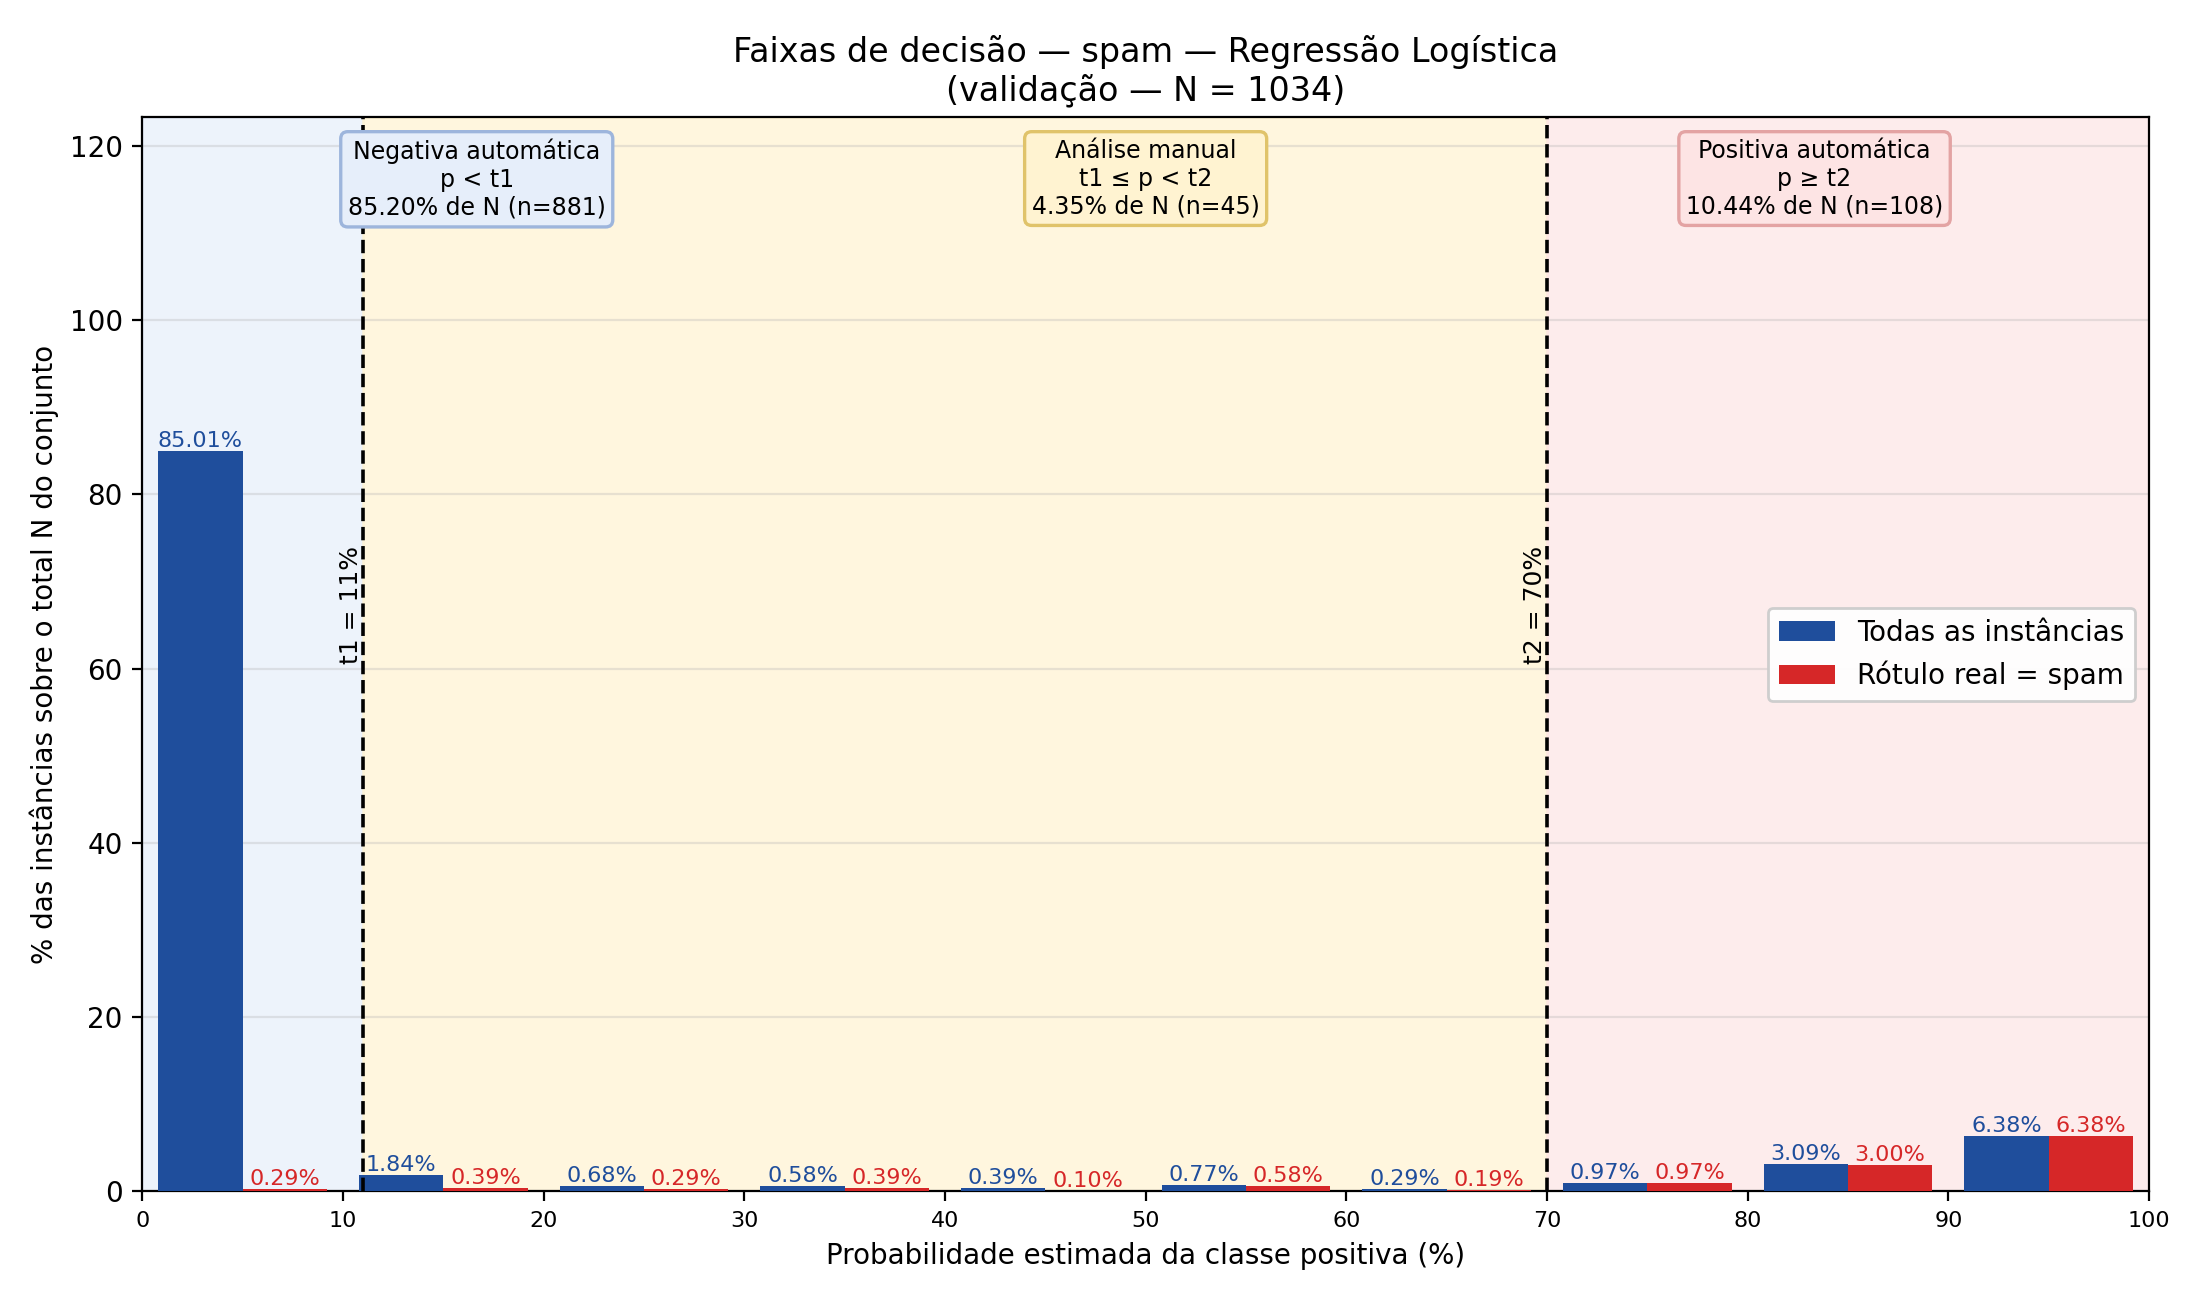

In [14]:
# Probabilidades do melhor modelo na validação
p_val = val_probas[best_name]
# Procura o melhor par (t1, t2) SÓ na validação, respeitando os limites de erro do domínio
(t1, t2), rep_val, tradeoff = cutoff_hist.choose_cutoffs(
    y_val, p_val, cfg["max_fn_rate"], cfg["max_fp_rate"])
print(f"t1 = {t1:.2f} | t2 = {t2:.2f}  (max_fn_rate = {cfg['max_fn_rate']} sobre positivos, "
      f"max_fp_rate = {cfg['max_fp_rate']} sobre negativos)")
# Tabela com os 10 melhores pares de cortes encontrados
table(tradeoff, "faixas/tradeoff_validacao")
# Quantos casos caíram em cada faixa e quantos positivos e negativos há em cada uma
table(rep_val["faixas"], "faixas/band_report_validacao_faixas")
# Erros das decisões automáticas, com o denominador de cada proporção
table(rep_val["erros"], "faixas/band_report_validacao_erros")
# Desenha o histograma com as faixas na validação
fig, _ = cutoff_hist.plot_cutoff_histogram(
    y_val, p_val, cfg["bin_width"], t1, t2, cfg["positive_label"],
    f"Faixas de decisão — {DOMAIN} — {best_name}", FX / "09_histograma_faixas_validacao.png",
    dataset_name="validação")
# Fecha a figura (já foi salva) e mostra a imagem salva
plt.close(fig)
show(FX / "09_histograma_faixas_validacao.png")

### 11b. Os mesmos cortes aplicados ao teste

Usamos **exatamente o mesmo t1 e t2** no teste, sem nenhum ajuste. Se os erros no teste passarem um pouco dos limites, isso é normal: os cortes foram escolhidos numa amostra e aplicados em outra.

,faixa,regra,n,pct_populacao_sobre_N,n_positivos,pct_positivos_sobre_n_faixa,n_negativos,pct_negativos_sobre_n_faixa
0,Negativa automática,p < t1,881,85.12,8,0.91,873,99.09
1,Análise manual,t1 ≤ p < t2,52,5.02,21,40.38,31,59.62
2,Positiva automática,p ≥ t2,102,9.86,102,100.00,0,0.00
3,Total,"t1 = 0.11, t2 = 0.7",1035,100.00,131,12.66,904,87.34


,metrica,valor,valor_pct,numerador,denominador,descricao_denominador,descricao
0,fn_auto,8.0000,NaN,8,<NA>,— (contagem),positivos classificados automaticamente como n...
1,fn_auto_sobre_positivos,0.0611,6.11,8,131,total de positivos,proporção dos positivos que caíram na faixa ne...
2,fn_auto_sobre_N,0.0077,0.77,8,1035,N (total de instâncias),proporção de N que é positivo e caiu na faixa ...
3,fp_auto,0.0000,NaN,0,<NA>,— (contagem),negativos classificados automaticamente como p...
4,fp_auto_sobre_negativos,0.0000,0.00,0,904,total de negativos,proporção dos negativos que caíram na faixa po...
5,fp_auto_sobre_N,0.0000,0.00,0,1035,N (total de instâncias),proporção de N que é negativo e caiu na faixa ...
6,cobertura_automatica,0.9498,94.98,983,1035,N (total de instâncias),proporção de N decidida automaticamente (fora ...
7,volume_manual,0.0502,5.02,52,1035,N (total de instâncias),proporção de N encaminhada à análise manual


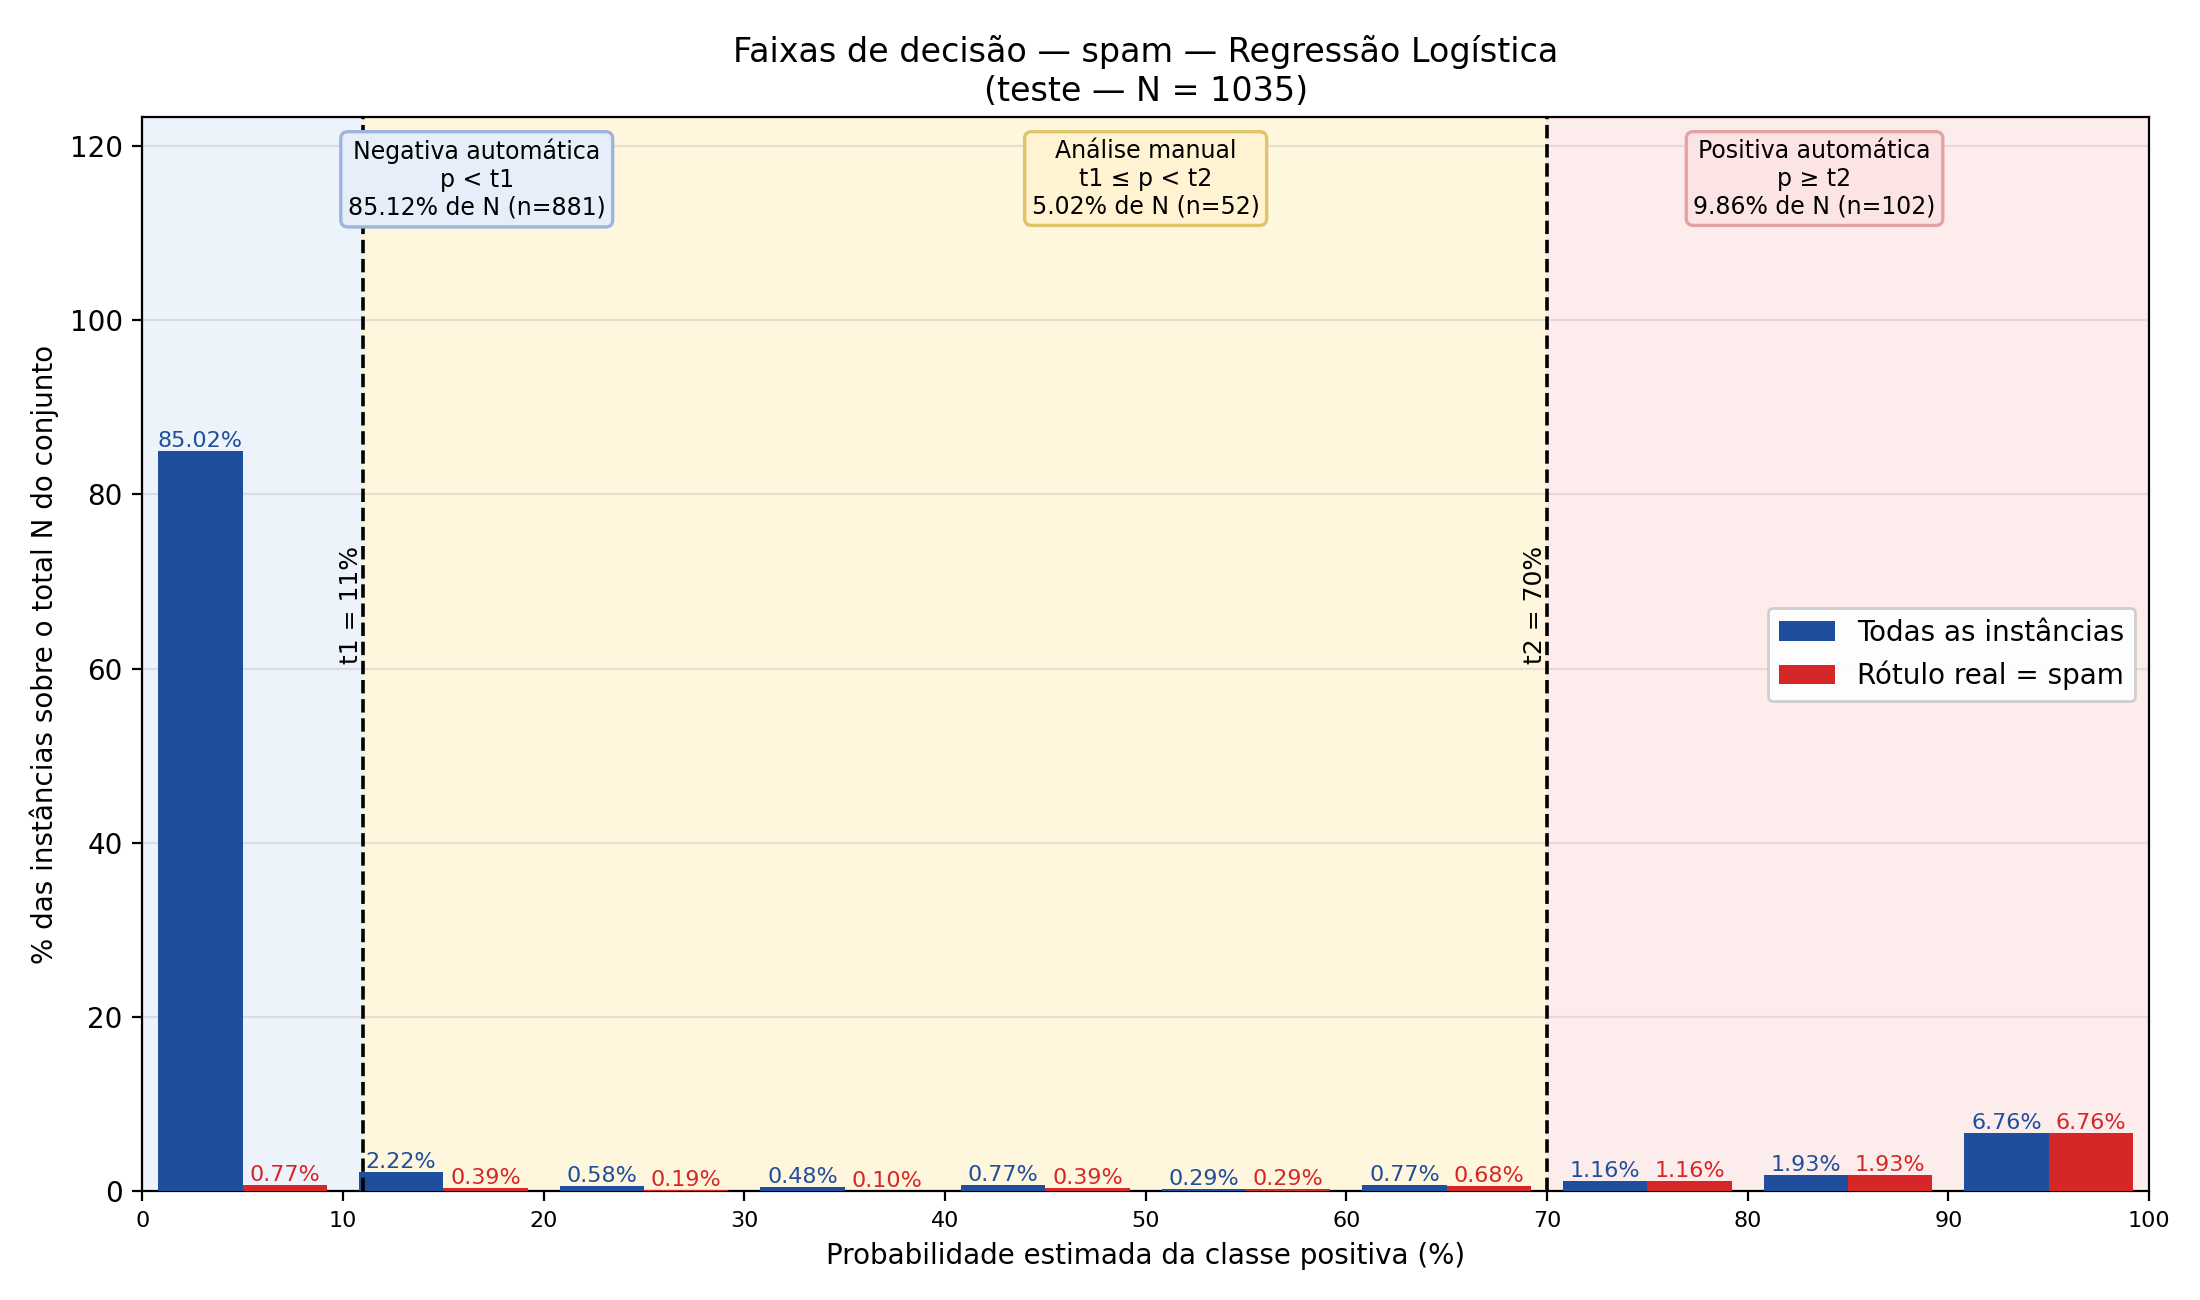

In [15]:
# Mesmas tabelas da validação, agora no teste, com os MESMOS t1 e t2
rep_test = cutoff_hist.band_report(y_te, p_test, t1, t2)
table(rep_test["faixas"], "faixas/band_report_teste_faixas")
table(rep_test["erros"], "faixas/band_report_teste_erros")
# Desenha o histograma com as faixas no teste
fig, _ = cutoff_hist.plot_cutoff_histogram(
    y_te, p_test, cfg["bin_width"], t1, t2, cfg["positive_label"],
    f"Faixas de decisão — {DOMAIN} — {best_name}", FX / "10_histograma_faixas_teste.png",
    dataset_name="teste")
plt.close(fig)
show(FX / "10_histograma_faixas_teste.png")
# Salva a resposta certa e a probabilidade de cada linha (é a entrada do programa da Parte 1)
pd.DataFrame({"y_true": y_val, "y_proba": p_val}).to_csv(OUT / "preds_validacao.csv", index=False)
pd.DataFrame({"y_true": y_te, "y_proba": p_test}).to_csv(OUT / "preds_teste.csv", index=False)

## 12. Resumo com todos os números

Junta todas as tabelas num único arquivo, `outputs/spam/resumo_resultados.md`, usado para escrever o relatório.

In [16]:
# Tabela com o tempo que cada etapa levou
tempos = pd.DataFrame({"etapa": list(pipeline.TIMINGS), "segundos": list(pipeline.TIMINGS.values())})
# Lista de blocos do resumo: (título, conteúdo)
blocos = [
    ("Balanceamento", balanceamento),
    ("Split 60/20/20", pipeline.split_table(splits)),
    (f"Hiperparâmetros vencedores (CV {config.CV_SPLITS} folds, {cfg['target_metric']})",
     hiperparametros),
    (f"Comparação na validação (limiar = {T})", comparacao),
    ("Melhor modelo", selecao),
    (f"Resultado no teste (limiar = {T})", resultado_teste),
    ("SHAP — informações", shap_res["info"]),
    ("SHAP — top 10 features (média |SHAP|)", shap_res["top10"]),
    ("Cortes (escolhidos na validação)",
     [f"t1 = {t1:.2f}", f"t2 = {t2:.2f}",
      f"max_fn_rate = {cfg['max_fn_rate']} (sobre positivos)",
      f"max_fp_rate = {cfg['max_fp_rate']} (sobre negativos)"]),
    ("Trade-off (10 melhores pares viáveis, validação)", tradeoff),
    ("band_report — validação — faixas", rep_val["faixas"]),
    ("band_report — validação — erros", rep_val["erros"].drop(columns="descricao")),
    ("band_report — teste — faixas", rep_test["faixas"]),
    ("band_report — teste — erros", rep_test["erros"].drop(columns="descricao")),
    ("Tempo de execução (s)", tempos),
    ("Figuras geradas", FIGS),
]
# Escreve o arquivo de resumo
resumo = evaluate.write_summary(OUT / "resumo_resultados.md",
                                f"Resumo de resultados — {DOMAIN}", blocos)
print("Resumo salvo em", resumo)

Resumo salvo em C:\Users\otavi\OneDrive\Desktop\data science\a2\outputs\spam\resumo_resultados.md
